# Figure 5 — Sweep results per $n$, curves by $\eta$

Loads the `(M, v_{\text{pop}})` samples persisted by `scripts/build_eta_pool.py`
(under `src/cache/eta_pool/<param_key>/eta{TT}/sample_NNNN/`), runs a uniform
bootstrap p-sweep on each, and plots `partition_agreement_M` vs $p$ — one
subplot per $n$, one curve per imbalance bin $\eta \in \{1, 5, 10, 15\}$.

Within an $\eta$ bin we average across the saved samples (mean ± std shading).
Sampling is **uniform** only; the metric is `partition_agreement_M` only.

## Cell 1 — Configuration

In [7]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.eta_pool_cache import (
    param_key, bin_name, list_completed_samples, load_pool_entry, pool_root,
)
from src.runners.p_sweep_inner import bootstrap_p_sweep_simple
from src.utils.sweep_cache import compute_or_load_sweep

CACHE_ROOT = PROJECT_ROOT / "src" / "cache"

# Pool key parameters (must match build_eta_pool.py defaults).
MU         = 0.1
POP_SIZE   = 1.0
SEQ_LEN    = 10_000
TREE_MODEL = "kingman"
SEQ_MODEL  = "JC69"
ETA_TARGETS = [1, 5, 10, 15]

# Sweep parameters. Trim BOOTSTRAP_REPS / P_VALUES if you add bigger n.
P_VALUES                    = np.geomspace(1e-3, 1.0, 25).tolist()
BOOTSTRAP_REPS              = 10
SEED                        = 0
NUM_GAPS                    = 10
MIN_SPLIT                   = 1
MAX_SAMPLES_PER_BIN         = 5  # cap per-(n, eta) work; bins may have 20+ saved samples
EARLY_STOP_CONSECUTIVE_100  = 2  # stop sweep once this many consecutive p's hit 100%
# 'sign' matches the eta-bin definition (n1, n2 from sign of v_pop) and avoids
# partition_taxa picking degenerate (1, n-1) outlier splits.
PARTITION_METHOD            = "sign"
USE_SWEEP_CACHE             = True  # reload prior bootstrap_p_sweep_simple outputs from disk

print(f"pool_root: {pool_root(CACHE_ROOT)}")
print(f"p_values ({len(P_VALUES)}): {[f'{p:.3g}' for p in P_VALUES]}")
print(f"max_samples_per_bin: {MAX_SAMPLES_PER_BIN}")
print(f"early_stop_consecutive_100: {EARLY_STOP_CONSECUTIVE_100}")
print(f"partition_method: {PARTITION_METHOD}")
print(f"use_sweep_cache: {USE_SWEEP_CACHE}")

pool_root: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/src/cache/eta_pool
p_values (25): ['0.001', '0.00133', '0.00178', '0.00237', '0.00316', '0.00422', '0.00562', '0.0075', '0.01', '0.0133', '0.0178', '0.0237', '0.0316', '0.0422', '0.0562', '0.075', '0.1', '0.133', '0.178', '0.237', '0.316', '0.422', '0.562', '0.75', '1']
max_samples_per_bin: 5
early_stop_consecutive_100: 2
partition_method: sign
use_sweep_cache: True


## Cell 2 — Discover available $n$ and saved samples

Walk `src/cache/eta_pool/`, parse the `n` from each `param_key` matching the
fixed `(L, μ, tree_model, pop_size, seq_model)` tuple, and report the sample
count per $\eta$ bin.

In [8]:
# Build the param_key suffix that all matching n's share, and look for keys
# that start with 'n{N}' and end with the same suffix.
key_suffix = param_key(
    n=0, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
    pop_size=POP_SIZE, seq_model=SEQ_MODEL,
).split("_", 1)[1]

ns = []
samples_by_n_eta = {}  # (n, eta_target) -> list[int] of completed sample idxs
for d in sorted(pool_root(CACHE_ROOT).iterdir()) if pool_root(CACHE_ROOT).exists() else []:
    if not d.is_dir() or not d.name.endswith(key_suffix):
        continue
    head = d.name.split("_", 1)[0]  # e.g. 'n0500'
    try:
        n = int(head[1:])
    except ValueError:
        continue
    key = d.name
    have_any = False
    for eta in ETA_TARGETS:
        idxs = list_completed_samples(CACHE_ROOT, key, eta)
        samples_by_n_eta[(n, eta)] = idxs
        have_any = have_any or bool(idxs)
    if have_any:
        ns.append(n)

ns = sorted(set(ns))
print(f"Found n values: {ns}")
print(f"\nSamples per (n, eta):")
print(f"  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in ETA_TARGETS))
for n in ns:
    counts = [len(samples_by_n_eta.get((n, e), [])) for e in ETA_TARGETS]
    print(f"  {n:>6}  " + "  ".join(f"{c:>6d}" for c in counts))

Found n values: [500, 1000, 2000, 4000]

Samples per (n, eta):
       n  eta= 1  eta= 5  eta=10  eta=15
     500       2       2       2       1
    1000      20      20      20      20
    2000      20      20      20      20
    4000      20      20      15       4


## Cell 3 — Run bootstrap p-sweeps

For each (n, η, sample), load the cached `(M, v_pop)` and call
`bootstrap_p_sweep_simple` (uniform sampling, partition_agreement_M).
Per-sample results are stored in `results[(n, eta)]` as a list of
agreement-curve arrays of length `len(P_VALUES)`.

In [9]:
results = {}  # (n, eta) -> np.ndarray of shape (n_samples, len(P_VALUES))

for n in ns:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
        pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta in ETA_TARGETS:
        idxs = samples_by_n_eta.get((n, eta), [])[:MAX_SAMPLES_PER_BIN]
        if not idxs:
            results[(n, eta)] = np.empty((0, len(P_VALUES)))
            continue
        rows = []
        for idx in idxs:
            def _loader(_key=key, _eta=eta, _idx=idx):
                entry = load_pool_entry(CACHE_ROOT, _key, _eta, _idx)
                if entry is None:
                    return None
                M, v_pop, _meta = entry
                return M, v_pop

            outcome = compute_or_load_sweep(
                cache_root=CACHE_ROOT, param_key=key, eta_target=eta, idx=idx,
                M_loader=_loader,
                p_values=P_VALUES,
                bootstrap_reps=BOOTSTRAP_REPS,
                seed=SEED,
                num_gaps=NUM_GAPS,
                min_split=MIN_SPLIT,
                early_stop_consecutive_100=EARLY_STOP_CONSECUTIVE_100,
                partition_method=PARTITION_METHOD,
                use_cache=USE_SWEEP_CACHE,
            )
            if outcome is None:
                continue
            out, was_cached = outcome
            rows.append(out["partition_agreement_M"])
            tag = "cached" if was_cached else "computed"
            print(f"  n={n:>4}  eta={eta:>2}  sample={idx:>3}  "
                  f"split_ref={tuple(out['partition_split_ref'])}  "
                  f"agr@p_min={rows[-1][0]:5.1f}  agr@p_max={rows[-1][-1]:5.1f}  "
                  f"({tag})")
        results[(n, eta)] = np.asarray(rows) if rows else np.empty((0, len(P_VALUES)))

for (n, eta), arr in sorted(results.items()):
    print(f"  results[(n={n}, eta={eta})].shape = {arr.shape}")

  n= 500  eta= 1  sample=  1  split_ref=(206, 294)  agr@p_min= 55.0  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  2  split_ref=(189, 311)  agr@p_min= 51.8  agr@p_max=100.0  (computed)
  n= 500  eta= 5  sample=  1  split_ref=(93, 407)  agr@p_min= 53.8  agr@p_max=100.0  (computed)
  n= 500  eta= 5  sample=  2  split_ref=(82, 418)  agr@p_min= 50.2  agr@p_max=100.0  (computed)
  n= 500  eta=10  sample=  1  split_ref=(45, 455)  agr@p_min= 55.0  agr@p_max=100.0  (computed)
  n= 500  eta=10  sample=  2  split_ref=(50, 450)  agr@p_min= 56.0  agr@p_max=100.0  (computed)
  n= 500  eta=15  sample=  1  split_ref=(33, 467)  agr@p_min= 51.2  agr@p_max=100.0  (computed)
  n=1000  eta= 1  sample=  1  split_ref=(474, 526)  agr@p_min= 54.9  agr@p_max=100.0  (computed)
  n=1000  eta= 1  sample=  2  split_ref=(465, 535)  agr@p_min= 50.9  agr@p_max=100.0  (computed)
  n=1000  eta= 1  sample=  3  split_ref=(498, 502)  agr@p_min= 53.6  agr@p_max=100.0  (computed)
  n=1000  eta= 1  sample=  4  split_r

## Cell 4 — Plot: one subplot per $n$, curves by $\eta$

Within each $\eta$ bin, the solid line is the mean across saved samples and
the shaded band is ±1 std. Bins with zero samples are skipped silently.

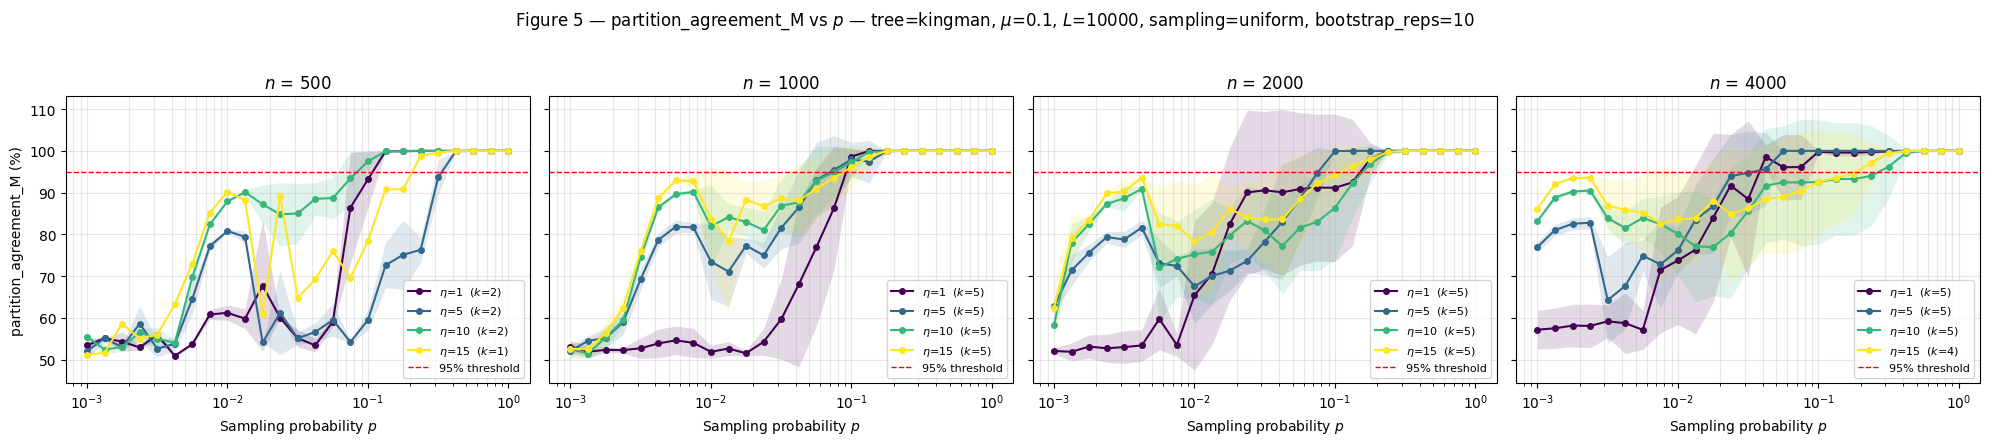

In [10]:
if not ns:
    print("No matching pool keys found — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    eta_to_color = {
        e: cmap(i / max(1, len(ETA_TARGETS) - 1))
        for i, e in enumerate(ETA_TARGETS)
    }

    fig, axes = plt.subplots(
        1, len(ns), figsize=(5 * len(ns), 4.5), sharey=True, squeeze=False,
    )
    axes = axes[0]
    fig.suptitle(
        fr"Figure 5 — partition_agreement_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, n in zip(axes, ns):
        for eta in ETA_TARGETS:
            arr = results.get((n, eta))
            if arr is None or arr.shape[0] == 0:
                continue
            mean = arr.mean(axis=0)
            std = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(mean)
            color = eta_to_color[eta]
            ax.plot(
                P_VALUES, mean, "-o", ms=4, lw=1.5, color=color,
                label=fr"$\eta$={eta}  ($k$={arr.shape[0]})",
            )
            if arr.shape[0] > 1:
                ax.fill_between(P_VALUES, mean - std, mean + std,
                                color=color, alpha=0.15, linewidth=0)

        ax.axhline(95.0, color="red", ls="--", lw=1, label="95% threshold")
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$n$ = {n}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    axes[0].set_ylabel("partition_agreement_M (%)")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

## Cell 5 — Plot 2 sweep: one sample per $(n, \eta)$, closest to bin target

For each $(n, \eta_{\text{target}})$, pick the cached sample whose measured
$\eta$ is closest to the target, run a single bootstrap p-sweep, and store
the result. No averaging across samples — one curve per $(n, \eta)$. This
mirrors the recovery-curves panel of `figure_4_kingman_real_sweep.ipynb`.

In [11]:
import json
from src.utils.eta_pool_cache import sample_dir

single_results = {}  # (n, eta_target) -> {"agreement", "eta_actual", "idx"}

for n in ns:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
        pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta_target in ETA_TARGETS:
        idxs = samples_by_n_eta.get((n, eta_target), [])
        if not idxs:
            continue

        # Read just metadata for each candidate to find the closest measured eta.
        candidates = []
        for idx in idxs:
            meta_path = sample_dir(CACHE_ROOT, key, eta_target, idx) / "metadata.json"
            if not meta_path.exists():
                continue
            with open(meta_path, "r") as f:
                meta = json.load(f)
            candidates.append((idx, float(meta["eta"])))
        if not candidates:
            continue

        idx_star, eta_actual = min(
            candidates, key=lambda t: abs(t[1] - float(eta_target))
        )

        def _loader(_key=key, _eta=eta_target, _idx=idx_star):
            entry = load_pool_entry(CACHE_ROOT, _key, _eta, _idx)
            if entry is None:
                return None
            M, v_pop, _meta = entry
            return M, v_pop

        outcome = compute_or_load_sweep(
            cache_root=CACHE_ROOT, param_key=key, eta_target=eta_target, idx=idx_star,
            M_loader=_loader,
            p_values=P_VALUES,
            bootstrap_reps=BOOTSTRAP_REPS,
            seed=SEED,
            num_gaps=NUM_GAPS,
            min_split=MIN_SPLIT,
            early_stop_consecutive_100=EARLY_STOP_CONSECUTIVE_100,
            partition_method=PARTITION_METHOD,
            use_cache=USE_SWEEP_CACHE,
        )
        if outcome is None:
            continue
        out, was_cached = outcome
        agr = np.asarray(out["partition_agreement_M"], dtype=float)
        single_results[(n, eta_target)] = {
            "agreement": agr,
            "eta_actual": eta_actual,
            "idx": idx_star,
        }
        tag = "cached" if was_cached else "computed"
        print(
            f"  n={n:>4}  eta_target={eta_target:>2}  idx={idx_star:>3}  "
            f"eta_actual={eta_actual:5.2f}  "
            f"agr@p_min={agr[0]:5.1f}  agr@p_max={agr[-1]:5.1f}  ({tag})"
        )

print(f"\nselected {len(single_results)} (n, eta_target) curves")

  n= 500  eta_target= 1  idx=  1  eta_actual= 1.43  agr@p_min= 55.0  agr@p_max=100.0  (cached)
  n= 500  eta_target= 5  idx=  2  eta_actual= 5.10  agr@p_min= 50.2  agr@p_max=100.0  (cached)
  n= 500  eta_target=10  idx=  1  eta_actual=10.11  agr@p_min= 55.0  agr@p_max=100.0  (cached)
  n= 500  eta_target=15  idx=  1  eta_actual=14.15  agr@p_min= 51.2  agr@p_max=100.0  (cached)
  n=1000  eta_target= 1  idx=  3  eta_actual= 1.01  agr@p_min= 53.6  agr@p_max=100.0  (cached)
  n=1000  eta_target= 5  idx=  9  eta_actual= 4.99  agr@p_min= 52.5  agr@p_max=100.0  (computed)
  n=1000  eta_target=10  idx=  3  eta_actual=10.11  agr@p_min= 52.6  agr@p_max=100.0  (cached)
  n=1000  eta_target=15  idx=  4  eta_actual=14.87  agr@p_min= 51.3  agr@p_max=100.0  (cached)
  n=2000  eta_target= 1  idx= 10  eta_actual= 1.00  agr@p_min= 51.5  agr@p_max=100.0  (computed)
  n=2000  eta_target= 5  idx= 12  eta_actual= 5.02  agr@p_min= 64.4  agr@p_max=100.0  (computed)
  n=2000  eta_target=10  idx= 19  eta_actual

## Cell 6 — Plot 2: one subplot per $\eta$, curves by $n$

Mirrors the recovery-curves panel of `figure_4_kingman_real_sweep.ipynb`:
each subplot fixes a $\eta$ bin, and each curve is a different $n$. Only one
sample per curve (closest measured $\eta$ to the bin target).

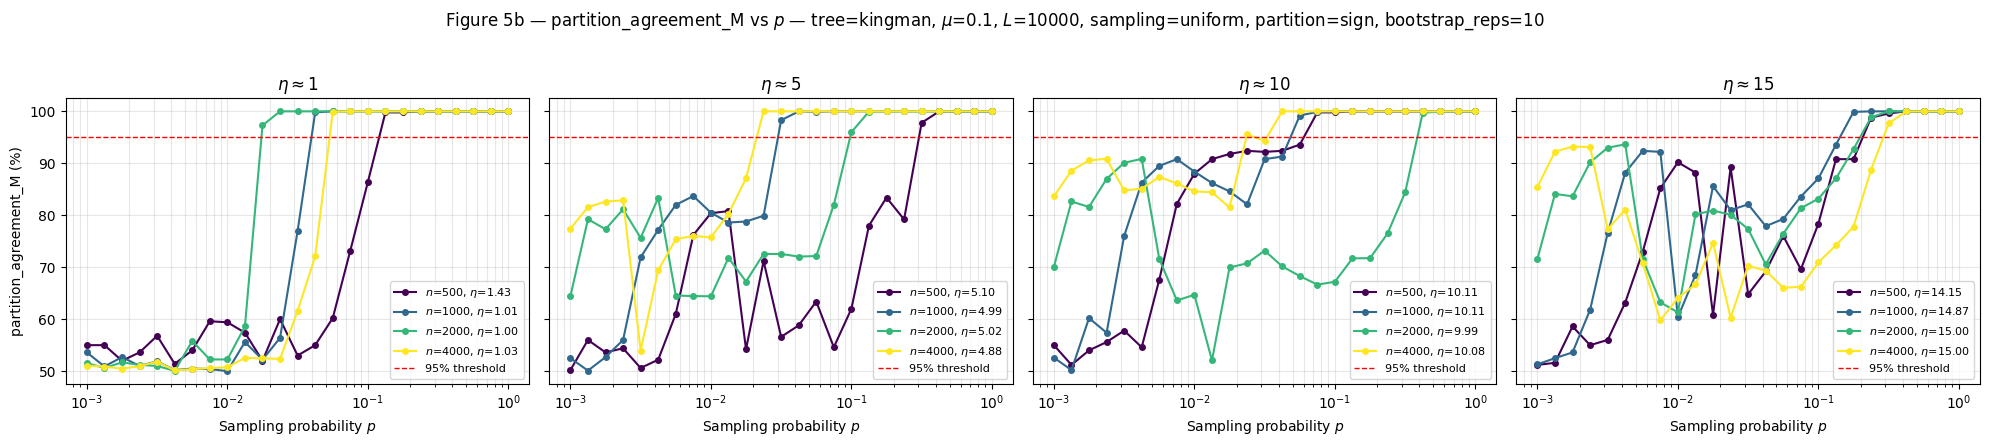

In [12]:
if not single_results:
    print("No single-sample sweeps available — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    n_to_color = {
        n: cmap(i / max(1, len(ns) - 1))
        for i, n in enumerate(ns)
    }

    fig, axes = plt.subplots(
        1, len(ETA_TARGETS), figsize=(5 * len(ETA_TARGETS), 4.5),
        sharey=True, squeeze=False,
    )
    axes = axes[0]
    fig.suptitle(
        fr"Figure 5b — partition_agreement_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"partition={PARTITION_METHOD}, bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, eta_target in zip(axes, ETA_TARGETS):
        for n in ns:
            entry = single_results.get((n, eta_target))
            if entry is None:
                continue
            ax.plot(
                P_VALUES, entry["agreement"], "-o", ms=4, lw=1.5,
                color=n_to_color[n],
                label=fr"$n$={n}, $\eta$={entry['eta_actual']:.2f}",
            )

        ax.axhline(95.0, color="red", ls="--", lw=1, label="95% threshold")
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$\eta \approx {eta_target}$")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    axes[0].set_ylabel("partition_agreement_M (%)")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()